<a href="https://colab.research.google.com/github/wajeeha-urooj/protein-mutation-analyzer/blob/main/Protein_Mutation_Analyzer_Improved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Protein Mutation Analyzer

## Project Overview

Protein mutations can alter amino-acid composition, physicochemical properties, and potentially the structural or functional behavior of proteins.

In this project, we develop a reusable Python-based workflow for comparing a wild-type protein sequence with a mutant protein sequence.

The analysis uses the human TP53 protein as a real biological example. The reference protein is TP53 (UniProtKB P04637), a reviewed human protein consisting of 393 amino acids. A documented TP53 variant, p.Arg175His (R175H), is used as the mutant example. The variant is recorded in ClinVar as a change from arginine to histidine at protein position 175.

The purpose of this project is not to predict clinical outcomes directly. Instead, the workflow focuses on computational characterization of the protein sequence change.

## Objectives

The main objectives are to:

1. Obtain a real protein reference sequence from UniProt.
2. Create a mutant protein sequence corresponding to a documented amino-acid variant.
3. Compare wild-type and mutant protein sequences.
4. Identify amino-acid substitutions, insertions and deletions.
5. Compare basic physicochemical properties of the residues and of the whole proteins.
6. Score the substitution with standard measures (BLOSUM62 and the Grantham distance).
7. Place the variant in its local sequence context and in the annotated protein domains.
8. Visualize mutation position and property changes.
9. Compare several variants of the same protein in one table.
10. Generate a structured mutation report and export the analysis results.

## Biological Example

**Protein:** TP53
**UniProt accession:** P04637
**Organism:** Homo sapiens
**Reference length:** 393 amino acids
**Variant:** p.Arg175His (R175H)

The project is designed to be reusable. To analyze another protein or another variant, only the two settings in section 2 need to be changed: `UNIPROT_ID` and `VARIANT`.

## Important Scope

This project is **protein-only**.

It does not perform:

* DNA sequence analysis
* nucleotide mutation analysis
* DNA-to-protein translation
* codon analysis
* synonymous/missense/nonsense classification at the nucleotide level

The focus is entirely on comparing protein sequences and characterizing amino-acid changes. Only single amino-acid substitutions can be entered as a variant. Insertions and deletions are handled by the comparison function in section 8.

## Workflow

**Reference protein → Mutant protein → Sequence comparison → Mutation detection → Property analysis → Substitution scores → Annotation context → Visualization → Report**

## How to Run

Run the cells from top to bottom. In Google Colab, use **Runtime → Run all**. The notebook needs an internet connection because the reference sequence and its annotations come from UniProt.

## 1. Environment Setup

We will install and import the Python libraries required for this project.

Biopython provides the protein-analysis tools and the sequence alignment, pandas organizes the results into tables, matplotlib creates the figures, and requests downloads data from UniProt.

After running the setup cells, the notebook prints the installed versions. Recording the versions makes the analysis easier to reproduce.

In [1]:
!pip install -q biopython pandas matplotlib requests numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 33.4 MB/s eta 0:00:00


In [2]:
import hashlib
import json
import math
import re
import shutil
import sys
from datetime import datetime, timezone
from io import StringIO
from pathlib import Path

import Bio
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from IPython.display import display

from Bio import SeqIO
from Bio.Align import PairwiseAligner, substitution_matrices
from Bio.Data import IUPACData
from Bio.SeqUtils import ProtParamData
from Bio.SeqUtils.ProtParam import ProteinAnalysis

print("Python version:", sys.version.split()[0])
print("Biopython version:", Bio.__version__)
print("Pandas version:", pd.__version__)
print("Environment ready!")

Python version: 3.13.15
Biopython version: 1.88
Pandas version: 2.2.3
Environment ready!


## 2. Configuration

We will define the biological reference and variant used in this analysis.

### Reference protein

The reference protein is human TP53:

* UniProt accession: P04637
* Protein name: Cellular tumor antigen p53
* Organism: Homo sapiens

### Variant

The protein variant analyzed in this project is:

**p.Arg175His (R175H)**

This represents a substitution of arginine (R) by histidine (H) at amino-acid position 175.

The variant is documented in ClinVar under TP53 and is linked to UniProt protein accession P04637.

The variant is written once, as `VARIANT`. The notebook reads the wild-type residue, the position and the mutant residue from it, and it accepts one-letter notation (R175H, p.R175H) as well as three-letter notation (p.Arg175His). Writing the variant in one place avoids the mistake of typing a name that does not match the numbers.

The sequence analysis in this notebook will focus on the protein-level change.

In [3]:
# Reference protein and variant

UNIPROT_ID = "P04637"

# One-letter (R175H or p.R175H) or three-letter (p.Arg175His) notation
VARIANT = "R175H"

THREE_TO_ONE = {
    "Ala": "A", "Arg": "R", "Asn": "N", "Asp": "D", "Cys": "C", "Gln": "Q", "Glu": "E",
    "Gly": "G", "His": "H", "Ile": "I", "Leu": "L", "Lys": "K", "Met": "M", "Phe": "F",
    "Pro": "P", "Ser": "S", "Thr": "T", "Trp": "W", "Tyr": "Y", "Val": "V",
}
ONE_TO_THREE = {one: three for three, one in THREE_TO_ONE.items()}


def parse_variant(text):
    """Turn 'R175H', 'p.R175H' or 'p.Arg175His' into (wild-type, position, mutant) in one-letter code."""
    match = re.fullmatch(r"(?:p\.)?([A-Za-z*]{1,3})(\d+)([A-Za-z*=]{1,3})", text.strip())
    if not match:
        raise ValueError(f"Could not read the variant '{text}'. Use a form such as R175H or p.Arg175His.")

    def one_letter(code):
        if len(code) == 1 and code.upper() in ONE_TO_THREE:
            return code.upper()
        if len(code) == 3 and code.title() in THREE_TO_ONE:
            return THREE_TO_ONE[code.title()]
        raise ValueError(
            f"'{code}' is not a standard amino acid. Only single amino-acid substitutions are supported."
        )

    wildtype = one_letter(match.group(1))
    position = int(match.group(2))
    mutant = one_letter(match.group(3))

    if wildtype == mutant:
        raise ValueError(f"'{text}' does not change the amino acid.")
    if position < 1:
        raise ValueError("The position must be 1 or higher.")
    return wildtype, position, mutant


WILDTYPE_AA, MUTATION_POSITION, MUTANT_AA = parse_variant(VARIANT)

VARIANT_TAG = f"{WILDTYPE_AA}{MUTATION_POSITION}{MUTANT_AA}"
VARIANT_NAME = (
    f"p.{ONE_TO_THREE[WILDTYPE_AA]}{MUTATION_POSITION}{ONE_TO_THREE[MUTANT_AA]} ({VARIANT_TAG})"
)

# Every file created by the notebook is saved in this folder
OUTPUT_DIR = Path(f"results_{UNIPROT_ID}_{VARIANT_TAG}")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Reference protein:", UNIPROT_ID)
print("Variant:", VARIANT_NAME)
print("Position:", MUTATION_POSITION)
print("Results folder:", OUTPUT_DIR)

Reference protein: P04637
Variant: p.Arg175His (R175H)
Position: 175
Results folder: results_P04637_R175H


## 3. Retrieve the Reference Protein

We will retrieve the TP53 reference protein sequence directly from the UniProt REST service.

Using a public biological database rather than manually typing a protein sequence makes the workflow reproducible and reduces the possibility of transcription errors.

The sequence will be retrieved in FASTA format and parsed using Biopython.

The download is wrapped in a function that explains what went wrong when the accession does not exist or when UniProt cannot be reached.

In [4]:
def fetch_uniprot_fasta(accession):
    """Download the FASTA text of a UniProtKB entry."""
    url = f"https://rest.uniprot.org/uniprotkb/{accession}.fasta"

    try:
        response = requests.get(url, timeout=30)
    except requests.RequestException as error:
        raise RuntimeError(
            f"Could not reach UniProt ({error}). Check the internet connection and run this cell again."
        ) from error

    if response.status_code in (400, 404, 410):
        raise ValueError(f"UniProt has no entry called '{accession}'. Check the accession in section 2.")

    response.raise_for_status()
    return response.text


fasta_text = fetch_uniprot_fasta(UNIPROT_ID)

print("UniProt sequence retrieved successfully.")
print(fasta_text[:300])

UniProt sequence retrieved successfully.
>sp|P04637|P53_HUMAN Cellular tumor antigen p53 OS=Homo sapiens OX=9606 GN=TP53 PE=1 SV=4
MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLSPDDIEQWFTEDPGP
DEAPRMPEAAPPVAPAPAAPTPAAPAPAPSWPLSSSVPSQKTYQGSYGFRLGFLHSGTAK
SVTCTYSPALNKMFCQLAKTCPVQLWVDSTPPPGTRVRAMAIYKQSQHMTEVVRRCPHHE
RCSDSDGLAPPQHLIRVEGNLRVEYLD


In [5]:
record = SeqIO.read(
    StringIO(fasta_text),
    "fasta"
)

wildtype_sequence = str(record.seq).upper()

# The gene name and the sequence version are written in the FASTA header (GN=... and SV=...)
gene_match = re.search(r"GN=(\S+)", record.description)
version_match = re.search(r"SV=(\d+)", record.description)

GENE_NAME = gene_match.group(1) if gene_match else UNIPROT_ID
SEQUENCE_VERSION = version_match.group(1) if version_match else "unknown"
RETRIEVED_ON = datetime.now(timezone.utc).strftime("%Y-%m-%d")
SEQUENCE_SHA256 = hashlib.sha256(wildtype_sequence.encode()).hexdigest()

# Keep a copy of the exact sequence that was analyzed
(OUTPUT_DIR / f"{UNIPROT_ID}.fasta").write_text(fasta_text)

print("Protein ID:", record.id)
print("Description:", record.description)
print("Gene:", GENE_NAME)
print("UniProt sequence version:", SEQUENCE_VERSION)
print("Retrieved on:", RETRIEVED_ON)
print("Sequence length:", len(wildtype_sequence))

Protein ID: sp|P04637|P53_HUMAN
Description: sp|P04637|P53_HUMAN Cellular tumor antigen p53 OS=Homo sapiens OX=9606 GN=TP53 PE=1 SV=4
Gene: TP53
UniProt sequence version: 4
Retrieved on: 2026-09-21
Sequence length: 393


### 3.1 Checking the Reference Sequence

Before any calculation, we will check that the reference sequence contains only the 20 standard amino acids.

The physicochemical calculations in Biopython cannot handle ambiguous or unusual letters such as X, B, Z or U. If the sequence contains one of them, it is better to stop here with a clear message than to fail later with an unclear error.

In [6]:
STANDARD_AMINO_ACIDS = set("ACDEFGHIKLMNPQRSTVWY")

unusual_letters = sorted(set(wildtype_sequence) - STANDARD_AMINO_ACIDS)

if unusual_letters:
    raise ValueError(
        f"The reference sequence contains letters that are not standard amino acids: {unusual_letters}. "
        "The property calculations below cannot handle them."
    )

print("Sequence check passed: only the 20 standard amino acids are present.")

Sequence check passed: only the 20 standard amino acids are present.


## 4. Inspecting the Reference Protein

We will look at the beginning of the protein and at the region around the mutation position.

Inspecting the sequence directly is a simple way to catch problems early, such as a wrong accession, a wrong protein or a variant position that lies outside the protein.

In [7]:
print("Protein:", record.id)
print("Length:", len(wildtype_sequence))
print("\nFirst 60 amino acids:")
print(wildtype_sequence[:60])

Protein: sp|P04637|P53_HUMAN
Length: 393

First 60 amino acids:
MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLSPDDIEQWFTEDPGP


In [8]:
# The position must lie inside the protein
if not 1 <= MUTATION_POSITION <= len(wildtype_sequence):
    raise ValueError(
        f"Position {MUTATION_POSITION} is outside the protein, which has {len(wildtype_sequence)} residues."
    )

# max() keeps the slice valid for variants near the start of the protein
start = max(0, MUTATION_POSITION - 6)
end = MUTATION_POSITION + 5

print(f"Sequence region surrounding position {MUTATION_POSITION}:")
print(wildtype_sequence[start:end])

print(f"\nResidue at position {MUTATION_POSITION}:")
print(wildtype_sequence[MUTATION_POSITION - 1])

Sequence region surrounding position 175:
TEVVRRCPHHE

Residue at position 175:
R


## 5. Verify the Mutation Position

We will confirm that the amino-acid position given in the variant contains the expected wild-type residue. For the p.Arg175His variant, position 175 of the UniProt reference sequence should contain arginine (R).

A mutation should never be applied blindly to a sequence.

Before generating the mutant sequence, the program should verify that:

**Reference residue = expected wild-type residue**

This is an important validation step in a reusable mutation-analysis workflow. A mismatch usually means that the variant was numbered on a different protein isoform or a different reference sequence than the one downloaded here.

In [9]:
observed_residue = wildtype_sequence[MUTATION_POSITION - 1]

print("Expected residue:", WILDTYPE_AA)
print("Observed residue:", observed_residue)

if observed_residue == WILDTYPE_AA:
    print("Validation successful: reference residue matches.")
else:
    raise ValueError(
        f"Reference mismatch: expected {WILDTYPE_AA}, "
        f"but found {observed_residue}. "
        "Check the accession and whether the variant is numbered on the same isoform."
    )

Expected residue: R
Observed residue: R
Validation successful: reference residue matches.


## 6. Generate the Mutant Protein Sequence

We will generate the mutant protein sequence by replacing the amino acid at the given position, for the example variant:

**R → H**

The sequence length remains unchanged because this is a single amino-acid substitution.

A mutation analyzer needs both the reference and altered protein sequences so that the two can be compared computationally.

The original wild-type sequence will be preserved.

In [10]:
mutant_sequence = (
    wildtype_sequence[:MUTATION_POSITION - 1]
    + MUTANT_AA
    + wildtype_sequence[MUTATION_POSITION:]
)

print("Wild-type length:", len(wildtype_sequence))
print("Mutant length:", len(mutant_sequence))

Wild-type length: 393
Mutant length: 393


In [11]:
print("Wild-type residue:")
print(wildtype_sequence[MUTATION_POSITION - 1])

print("\nMutant residue:")
print(mutant_sequence[MUTATION_POSITION - 1])

Wild-type residue:
R

Mutant residue:
H


## 7. Validate the Mutant Sequence

We will confirm that the mutation was introduced at the intended position and that all other sequence positions remain unchanged.

A robust computational workflow should verify its own modifications.

For a single amino-acid substitution:

* sequence lengths should remain equal
* exactly one position should differ
* the changed position should correspond to the requested mutation

In [12]:
differences = []

for i, (wt, mut) in enumerate(
    zip(wildtype_sequence, mutant_sequence),
    start=1
):
    if wt != mut:
        differences.append({
            "Position": i,
            "Wild_Type": wt,
            "Mutant": mut
        })

difference_df = pd.DataFrame(differences)

display(difference_df)

,Position,Wild_Type,Mutant
0,175,R,H


In [13]:
assert len(wildtype_sequence) == len(mutant_sequence)
assert len(differences) == 1
assert differences[0]["Position"] == MUTATION_POSITION
assert differences[0]["Wild_Type"] == WILDTYPE_AA
assert differences[0]["Mutant"] == MUTANT_AA

print("Mutation validation successful.")

Mutation validation successful.


## 8. Reusable Protein Mutation Detection

We will create a general function that compares two protein sequences and identifies the differences between them.

A reusable bioinformatics tool should not depend on one specific protein.

The function should work with other wild-type and mutant protein sequences provided by the user.

The comparison will report:

* mutation position
* wild-type amino acid
* mutant amino acid
* mutation type (substitution, insertion or deletion)
* a short notation, such as R175H

For sequences of equal length, the sequences are compared position by position and every difference is a substitution.

When the lengths differ, comparing position by position would wrongly report every residue after an insertion or deletion as changed. In that case the two sequences are **aligned** first, using a global pairwise alignment with the BLOSUM62 matrix, and the gaps in the alignment are reported as insertions and deletions.

Positions always refer to the wild-type sequence. When an insertion or deletion sits inside a repeated stretch of sequence, the exact position of the gap can be ambiguous, and any alignment method will share this limitation.

In [14]:
def _substitution(position, wildtype_residue, mutant_residue):
    return {
        "Position": position,
        "Wild_Type": wildtype_residue,
        "Mutant": mutant_residue,
        "Mutation_Type": "Substitution",
        "Notation": f"{wildtype_residue}{position}{mutant_residue}",
    }


def _deletion(start, deleted):
    end = start + len(deleted) - 1
    if len(deleted) == 1:
        notation = f"{deleted}{start}del"
    else:
        notation = f"{deleted[0]}{start}_{deleted[-1]}{end}del"
    return {"Position": start, "Wild_Type": deleted, "Mutant": "-",
            "Mutation_Type": "Deletion", "Notation": notation}


def _insertion(after_position, inserted, wildtype):
    # "Position" is the wild-type residue that comes just before the inserted residues
    if 0 < after_position < len(wildtype):
        notation = (f"{wildtype[after_position - 1]}{after_position}_"
                    f"{wildtype[after_position]}{after_position + 1}ins{inserted}")
    else:
        notation = f"ins{inserted} after position {after_position}"
    return {"Position": after_position, "Wild_Type": "-", "Mutant": inserted,
            "Mutation_Type": "Insertion", "Notation": notation}


def compare_proteins(wildtype, mutant):
    """
    Compare a wild-type and a mutant protein sequence.

    Returns a list of substitutions, insertions and deletions. Positions refer to the
    wild-type sequence and start at 1.

    Sequences of equal length are compared position by position. If the lengths differ,
    the sequences are aligned first. When an insertion or deletion sits inside a repeat,
    the exact position of the gap can be ambiguous.
    """
    if not wildtype or not mutant:
        raise ValueError("Both protein sequences must contain at least one amino acid.")

    events = []

    if len(wildtype) == len(mutant):
        for i, (wt, mut) in enumerate(zip(wildtype, mutant), start=1):
            if wt != mut:
                events.append(_substitution(i, wt, mut))
        return events

    aligner = PairwiseAligner()
    aligner.mode = "global"
    aligner.substitution_matrix = substitution_matrices.load("BLOSUM62")
    aligner.open_gap_score = -10
    aligner.extend_gap_score = -0.5
    alignment = aligner.align(wildtype, mutant)[0]

    wt_blocks, mut_blocks = alignment.aligned
    blocks = [((int(a), int(b)), (int(c), int(d))) for (a, b), (c, d) in zip(wt_blocks, mut_blocks)]
    blocks.append(((len(wildtype), len(wildtype)), (len(mutant), len(mutant))))   # closes the ends

    wt_done = 0
    mut_done = 0

    for (wt_start, wt_stop), (mut_start, mut_stop) in blocks:
        if wt_start > wt_done:
            events.append(_deletion(wt_done + 1, wildtype[wt_done:wt_start]))
        if mut_start > mut_done:
            events.append(_insertion(wt_done, mutant[mut_done:mut_start], wildtype))

        for offset in range(wt_stop - wt_start):
            wt = wildtype[wt_start + offset]
            mut = mutant[mut_start + offset]
            if wt != mut:
                events.append(_substitution(wt_start + offset + 1, wt, mut))

        wt_done, mut_done = wt_stop, mut_stop

    events.sort(key=lambda event: event["Position"])
    return events

In [15]:
mutation_results = compare_proteins(
    wildtype_sequence,
    mutant_sequence
)

mutation_df = pd.DataFrame(mutation_results)

display(mutation_df)

,Position,Wild_Type,Mutant,Mutation_Type,Notation
0,175,R,H,Substitution,R175H


### 8.1 Testing the Comparison Function

We will test the function on cases where the correct answer is known before relying on it.

The tests use a short artificial protein with no repeated segments, so they do not depend on the protein chosen in section 2. They cover: identical sequences, one substitution, a deletion, an insertion, a missing start, a missing end, and a substitution together with a deletion.

If one of the lines below fails, the function is wrong and the rest of the notebook should not be trusted.

In [16]:
TEST_PROTEIN = "MKTAYIAKQRQISFVKSHFSRQLEERLGLIEVQAPILSRVGDGTQDNLSGAEKAVQVKVKALPDAQFEVV"


def notations(wildtype, mutant):
    return [event["Notation"] for event in compare_proteins(wildtype, mutant)]


t = TEST_PROTEIN

# identical sequences
assert compare_proteins(t, t) == []

# one substitution
assert notations(t, t[:9] + "W" + t[10:]) == [f"{t[9]}10W"]

# a deletion of 3 residues (positions 21 to 23) and an insertion of 2 residues after position 40
assert notations(t, t[:20] + t[23:]) == [f"{t[20]}21_{t[22]}23del"]
assert notations(t, t[:40] + "WW" + t[40:]) == [f"{t[39]}40_{t[40]}41insWW"]

# the first 5 residues missing and the last 8 residues missing
assert compare_proteins(t, t[5:])[0]["Wild_Type"] == t[:5]
assert compare_proteins(t, t[:-8])[0]["Wild_Type"] == t[-8:]

# a substitution and a deletion in the same protein
mixed = t[:9] + "W" + t[10:20] + t[23:]
assert sorted(notations(t, mixed)) == sorted([f"{t[9]}10W", f"{t[20]}21_{t[22]}23del"])

# empty input is refused
try:
    compare_proteins(t, "")
except ValueError:
    pass
else:
    raise AssertionError("An empty sequence should raise an error.")

print("compare_proteins passed all tests.")

compare_proteins passed all tests.


## 9. Insertion and Deletion Detection

We will compare the lengths of the wild-type and mutant proteins.

Protein variants are not always simple substitutions. Insertions and deletions can change the length of a protein sequence.

For the current TP53 R175H example, no insertion or deletion is expected because R175H is a single-residue substitution.

The workflow nevertheless includes length checking so that it can be extended to other protein variants.

In [17]:
length_difference = len(mutant_sequence) - len(wildtype_sequence)

print("Wild-type length:", len(wildtype_sequence))
print("Mutant length:", len(mutant_sequence))
print("Length difference:", length_difference)

if length_difference == 0:
    print("No length change detected.")
elif length_difference > 0:
    print(f"Possible insertion of {length_difference} residue(s).")
else:
    print(f"Possible deletion of {abs(length_difference)} residue(s).")

Wild-type length: 393
Mutant length: 393
Length difference: 0
No length change detected.


### 9.1 Example with an Insertion and a Deletion

The variant used in this notebook is a substitution, so the insertion and deletion part of the comparison function has not been used on the real protein yet.

We will therefore create two artificial mutants from the reference sequence, one with three residues removed and one with two residues added, and run the same function on them. This shows what the output looks like for variants that change the protein length. These two mutants are only demonstrations. They are not real variants.

In [18]:
if len(wildtype_sequence) < 40:
    print("The protein is too short for this demonstration.")
else:
    demo_start = min(120, len(wildtype_sequence) - 20)

    demo_deletion = wildtype_sequence[:demo_start] + wildtype_sequence[demo_start + 3:]
    demo_insertion = wildtype_sequence[:demo_start + 10] + "GG" + wildtype_sequence[demo_start + 10:]

    demo_events = []
    for name, demo_mutant in (("3-residue deletion", demo_deletion), ("2-residue insertion", demo_insertion)):
        for event in compare_proteins(wildtype_sequence, demo_mutant):
            demo_events.append({"Example": name, **event})

    display(pd.DataFrame(demo_events))

,Example,Position,Wild_Type,Mutant,Mutation_Type,Notation
0,3-residue deletion,121,SVT,-,Deletion,S121_T123del
1,2-residue insertion,130,-,GG,Insertion,L130_N131insGG


## 10. Amino-Acid Property Analysis

We will characterize the amino acids involved in the mutation using basic biochemical properties.

For this project, we will examine:

* Molecular weight
* Hydropathy
* Polarity
* Side-chain charge at physiological pH

An amino-acid substitution can change biochemical properties even when the overall protein length remains unchanged.

Comparing residue properties provides a computational description of how the substituted amino acids differ.

These measurements describe sequence-level physicochemical changes and should not be interpreted as direct proof of altered protein function.

In [19]:
# Simple two-class polarity scheme used in this notebook.
# Charge is not stored as a category here, because it depends on pH and is calculated in the next cell.
amino_acid_properties = {
    "A": {"name": "Alanine", "polarity": "nonpolar"},
    "R": {"name": "Arginine", "polarity": "polar"},
    "N": {"name": "Asparagine", "polarity": "polar"},
    "D": {"name": "Aspartic acid", "polarity": "polar"},
    "C": {"name": "Cysteine", "polarity": "polar"},
    "E": {"name": "Glutamic acid", "polarity": "polar"},
    "Q": {"name": "Glutamine", "polarity": "polar"},
    "G": {"name": "Glycine", "polarity": "nonpolar"},
    "H": {"name": "Histidine", "polarity": "polar"},
    "I": {"name": "Isoleucine", "polarity": "nonpolar"},
    "L": {"name": "Leucine", "polarity": "nonpolar"},
    "K": {"name": "Lysine", "polarity": "polar"},
    "M": {"name": "Methionine", "polarity": "nonpolar"},
    "F": {"name": "Phenylalanine", "polarity": "nonpolar"},
    "P": {"name": "Proline", "polarity": "nonpolar"},
    "S": {"name": "Serine", "polarity": "polar"},
    "T": {"name": "Threonine", "polarity": "polar"},
    "W": {"name": "Tryptophan", "polarity": "nonpolar"},
    "Y": {"name": "Tyrosine", "polarity": "polar"},
    "V": {"name": "Valine", "polarity": "nonpolar"},
}

assert set(amino_acid_properties) == STANDARD_AMINO_ACIDS

print("Wild-type amino acid:", WILDTYPE_AA, "-", amino_acid_properties[WILDTYPE_AA])
print("Mutant amino acid:", MUTANT_AA, "-", amino_acid_properties[MUTANT_AA])

Wild-type amino acid: R - {'name': 'Arginine', 'polarity': 'polar'}
Mutant amino acid: H - {'name': 'Histidine', 'polarity': 'polar'}


### 10.1 Detailed Residue Properties

We will compare numerical and biochemical properties of the wild-type and mutant amino acids involved in the mutation.

For the TP53 R175H variant, the comparison is between:

- Arginine (R), the wild-type residue
- Histidine (H), the mutant residue

The analysis will include:

- Molecular weight (of the free amino acid, taken from Biopython)
- Hydropathy (Kyte-Doolittle scale, taken from Biopython)
- Polarity class
- Approximate side-chain pKa
- Average side-chain charge at physiological pH (7.4)

Amino-acid substitutions can alter several biochemical characteristics even when the protein sequence length remains unchanged.

A numerical property comparison provides more detailed information than simply reporting whether two residues are classified as polar or nonpolar.

### Important interpretation note

Residue charge depends on pH, so it is calculated and not simply labelled. The average charge of an ionizable side chain follows from its pKa through the Henderson-Hasselbalch equation.

Arginine has a side-chain pKa near 12.5, so it stays almost fully positive at pH 7.4. Histidine has a side-chain pKa near 6.0, so only a small share of histidine side chains carry a positive charge at pH 7.4. Arginine and histidine therefore do not behave alike at physiological pH, even though both are often described as basic residues.

The pKa values are those of free side chains in water. Inside a folded protein the real pKa can be shifted by the surrounding residues, so the calculated charge is an estimate.

In [20]:
# Side-chain pKa values (Nelson and Cox, Lehninger Principles of Biochemistry)
SIDE_CHAIN_PKA = {"D": 3.65, "E": 4.25, "H": 6.00, "C": 8.18, "Y": 10.07, "K": 10.53, "R": 12.48}
POSITIVE_SIDE_CHAINS = {"H", "K", "R"}
NEGATIVE_SIDE_CHAINS = {"D", "E", "C", "Y"}


def side_chain_charge(aa, pH=7.4):
    """
    Average charge of a free side chain at a given pH, from the Henderson-Hasselbalch equation.
    Inside a folded protein the real pKa can be shifted, so this is an estimate.
    """
    if aa in POSITIVE_SIDE_CHAINS:
        return 1 / (1 + 10 ** (pH - SIDE_CHAIN_PKA[aa]))
    if aa in NEGATIVE_SIDE_CHAINS:
        return -1 / (1 + 10 ** (SIDE_CHAIN_PKA[aa] - pH))
    return 0.0


def residue_facts(aa):
    """Properties of one amino acid. Weights and hydropathy come from Biopython's tables."""
    return {
        "Residue": aa,
        "Name": amino_acid_properties[aa]["name"],
        "Molecular_Weight": IUPACData.protein_weights[aa],       # free amino acid, in Da
        "Hydropathy": ProtParamData.kd[aa],                       # Kyte-Doolittle scale
        "Side_Chain_pKa": SIDE_CHAIN_PKA.get(aa),
        "Charge_at_pH_7_4": side_chain_charge(aa, 7.4),
        "Polarity": amino_acid_properties[aa]["polarity"],
    }


wt_facts = residue_facts(WILDTYPE_AA)
mut_facts = residue_facts(MUTANT_AA)


def show(value, digits=2):
    return "not ionizable" if value is None else round(value, digits)


residue_comparison = pd.DataFrame({
    "Property": [
        "Residue",
        "Name",
        "Molecular weight (Da, free amino acid)",
        "Hydropathy (Kyte-Doolittle)",
        "Polarity class",
        "Side-chain pKa",
        "Side-chain charge at pH 7.4",
    ],
    "Wild_Type": [
        wt_facts["Residue"], wt_facts["Name"], show(wt_facts["Molecular_Weight"]),
        show(wt_facts["Hydropathy"]), wt_facts["Polarity"],
        show(wt_facts["Side_Chain_pKa"]), show(wt_facts["Charge_at_pH_7_4"]),
    ],
    "Mutant": [
        mut_facts["Residue"], mut_facts["Name"], show(mut_facts["Molecular_Weight"]),
        show(mut_facts["Hydropathy"]), mut_facts["Polarity"],
        show(mut_facts["Side_Chain_pKa"]), show(mut_facts["Charge_at_pH_7_4"]),
    ],
})

display(residue_comparison)

,Property,Wild_Type,Mutant
0,Residue,R,H
1,Name,Arginine,Histidine
2,"Molecular weight (Da, free amino acid)",174.2,155.15
3,Hydropathy (Kyte-Doolittle),-4.5,-3.2
4,Polarity class,polar,polar
5,Side-chain pKa,12.48,6.0
6,Side-chain charge at pH 7.4,1.0,0.04


In [21]:
molecular_weight_change = mut_facts["Molecular_Weight"] - wt_facts["Molecular_Weight"]
hydropathy_change = mut_facts["Hydropathy"] - wt_facts["Hydropathy"]
charge_delta = mut_facts["Charge_at_pH_7_4"] - wt_facts["Charge_at_pH_7_4"]

print(f"{VARIANT_TAG} residue property changes")
print("=" * 40)

print(f"Molecular weight change: {molecular_weight_change:+.2f} Da (free amino acids)")
print(f"Hydropathy change: {hydropathy_change:+.2f} (Kyte-Doolittle)")

if wt_facts["Side_Chain_pKa"] is not None and mut_facts["Side_Chain_pKa"] is not None:
    pka_change = mut_facts["Side_Chain_pKa"] - wt_facts["Side_Chain_pKa"]
    print(f"Side-chain pKa change: {pka_change:+.2f}")

print("\nCharge at pH 7.4 (average, from the side-chain pKa):")
print(f"{wt_facts['Name']}: {wt_facts['Charge_at_pH_7_4']:+.2f}")
print(f"{mut_facts['Name']}: {mut_facts['Charge_at_pH_7_4']:+.2f}")
print(f"Change: {charge_delta:+.2f}")

R175H residue property changes
Molecular weight change: -19.05 Da (free amino acids)
Hydropathy change: +1.30 (Kyte-Doolittle)
Side-chain pKa change: -6.48

Charge at pH 7.4 (average, from the side-chain pKa):
Arginine: +1.00
Histidine: +0.04
Change: -0.96


### 10.2 Numerical Property Changes

We will show the numerical differences as a figure.

The three properties have very different scales, for example a molecular weight of about 150 and a charge between 0 and 1. Plotting them on one axis would make the small values invisible. Each property therefore gets its own panel with its own scale, and the change is written in the panel title.

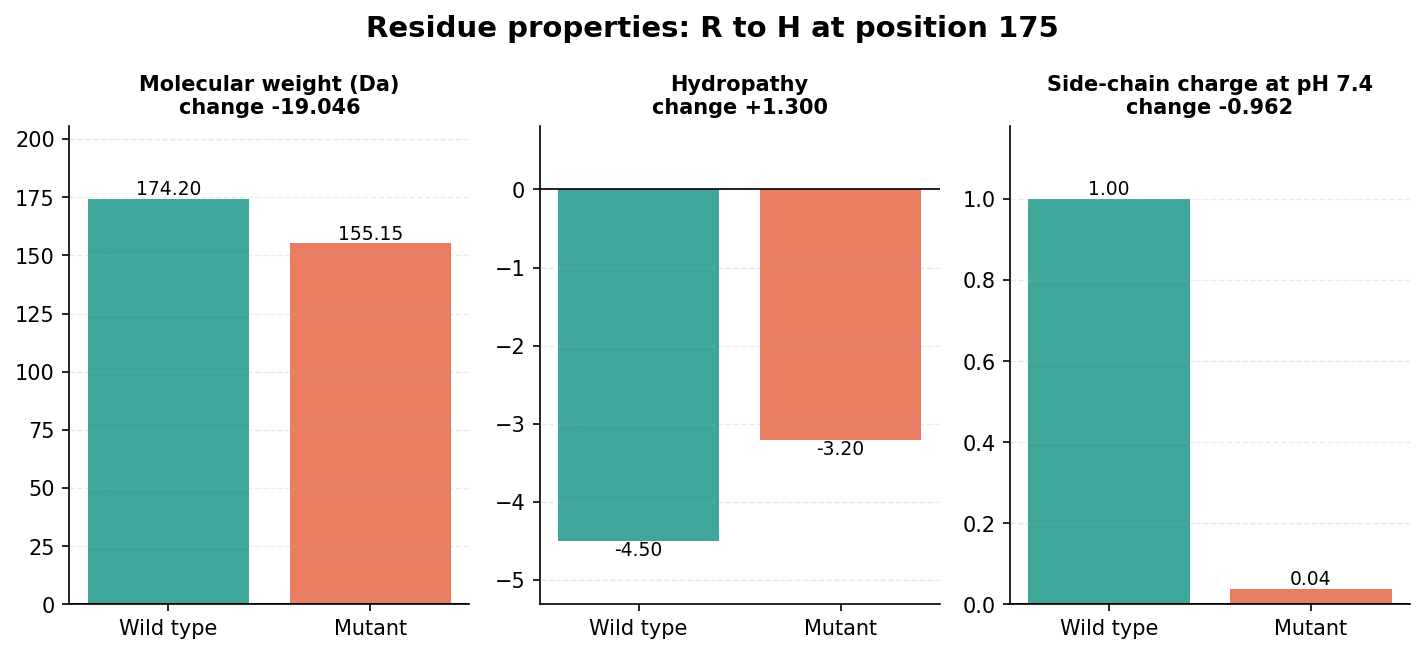

In [22]:
COLOR_WILD_TYPE = "#2A9D8F"
COLOR_MUTANT = "#E76F51"


def save_figure(fig, filename):
    """Save a figure in the results folder at print quality."""
    fig.savefig(OUTPUT_DIR / filename, dpi=300, bbox_inches="tight")


def plot_wt_vs_mutant(table, title, filename):
    """One small panel per property, each with its own scale, so large and small values stay readable."""
    n = len(table)
    fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 4.4), dpi=150)
    if n == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, table.iterrows()):
        values = [float(row["Wild_Type"]), float(row["Mutant"])]
        bars = ax.bar(["Wild type", "Mutant"], values, color=[COLOR_WILD_TYPE, COLOR_MUTANT], alpha=0.9)

        low, high = min(values + [0]), max(values + [0])
        span = (high - low) or 1
        ax.set_ylim(low - 0.18 * span if low < 0 else 0, high + 0.18 * span if high > 0 else 0.18 * span)
        ax.axhline(0, color="black", linewidth=0.8)

        for bar, value in zip(bars, values):
            ax.text(
                bar.get_x() + bar.get_width() / 2, value, f"{value:,.2f}",
                ha="center", va="bottom" if value >= 0 else "top", fontsize=9
            )

        ax.set_title(f"{row['Property']}\nchange {values[1] - values[0]:+,.3f}", fontsize=10, fontweight="bold")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.25)

    fig.suptitle(title, fontsize=14, fontweight="bold")
    fig.tight_layout()
    save_figure(fig, filename)
    plt.show()


numeric_properties = pd.DataFrame({
    "Property": ["Molecular weight (Da)", "Hydropathy", "Side-chain charge at pH 7.4"],
    "Wild_Type": [wt_facts["Molecular_Weight"], wt_facts["Hydropathy"], wt_facts["Charge_at_pH_7_4"]],
    "Mutant": [mut_facts["Molecular_Weight"], mut_facts["Hydropathy"], mut_facts["Charge_at_pH_7_4"]],
})

plot_wt_vs_mutant(
    numeric_properties,
    f"Residue properties: {WILDTYPE_AA} to {MUTANT_AA} at position {MUTATION_POSITION}",
    f"{VARIANT_TAG}_residue_property_comparison.png"
)

### 10.3 Substitution Scores

We will score the substitution with two standard measures that describe how different two amino acids are.

**BLOSUM62** is a substitution matrix built from conserved blocks of related proteins. A positive score means that the replacement is seen more often than expected by chance, a score of 0 means about as often as expected, and a negative score means less often. It measures how often one amino acid replaces another during evolution.

**The Grantham distance** combines three properties of the side chains, their composition, polarity and volume, into one number. A larger distance means a more different amino acid. A common way to read it is:

* 0 to 50: conservative
* 51 to 100: moderately conservative
* 101 to 150: moderately radical
* 151 and above: radical

The Grantham values here are calculated from the 1974 composition, polarity and volume values of each amino acid, so a result can differ by 1 from the printed matrix because of rounding of the inputs.

### Important interpretation note

Both scores describe the **type** of amino-acid change. They do not describe **where** in the protein the change happens. A conservative-looking substitution at a structurally critical position can be very damaging, and a radical substitution in a flexible region can be harmless. These scores are therefore a description and not a prediction of harm.

In [23]:
# Grantham (1974): composition, polarity and volume of each side chain
GRANTHAM_PROPERTIES = {
    "A": (0.00, 8.1, 31), "R": (0.65, 10.5, 124), "N": (1.33, 11.6, 56), "D": (1.38, 13.0, 54),
    "C": (2.75, 5.5, 55), "Q": (0.89, 10.5, 85), "E": (0.92, 12.3, 83), "G": (0.74, 9.0, 3),
    "H": (0.58, 10.4, 96), "I": (0.00, 5.2, 111), "L": (0.00, 4.9, 111), "K": (0.33, 11.3, 119),
    "M": (0.00, 5.7, 105), "F": (0.00, 5.2, 132), "P": (0.39, 8.0, 32.5), "S": (1.42, 9.2, 32),
    "T": (0.71, 8.6, 61), "W": (0.13, 5.4, 170), "Y": (0.20, 6.2, 136), "V": (0.00, 5.9, 84),
}


def grantham_distance(aa1, aa2):
    """Grantham distance between two amino acids (one-letter codes)."""
    c1, p1, v1 = GRANTHAM_PROPERTIES[aa1]
    c2, p2, v2 = GRANTHAM_PROPERTIES[aa2]
    distance = math.sqrt(1.833 * (c1 - c2) ** 2 + 0.1018 * (p1 - p2) ** 2 + 0.000399 * (v1 - v2) ** 2)
    return round(50.723 * distance)


def grantham_class(distance):
    if distance <= 50:
        return "conservative"
    if distance <= 100:
        return "moderately conservative"
    if distance <= 150:
        return "moderately radical"
    return "radical"


blosum62 = substitution_matrices.load("BLOSUM62")

# Check the calculation against entries of the published Grantham matrix (a difference of 1 is rounding)
published = {("R", "H"): 29, ("R", "K"): 26, ("R", "Q"): 43, ("R", "W"): 101, ("R", "C"): 180,
             ("L", "I"): 5, ("D", "E"): 45, ("G", "A"): 60, ("F", "Y"): 22, ("S", "T"): 58}
for (a, b), value in published.items():
    assert abs(grantham_distance(a, b) - value) <= 1, (a, b)
    assert grantham_distance(a, b) == grantham_distance(b, a)
assert grantham_distance("R", "R") == 0

print("Grantham calculation matches the published matrix for the check pairs.")
print()
print(f"{WILDTYPE_AA} to {MUTANT_AA}:")
print("BLOSUM62 score:", int(blosum62[WILDTYPE_AA, MUTANT_AA]))
print("Grantham distance:", grantham_distance(WILDTYPE_AA, MUTANT_AA),
      f"({grantham_class(grantham_distance(WILDTYPE_AA, MUTANT_AA))})")

Grantham calculation matches the published matrix for the check pairs.

R to H:
BLOSUM62 score: 0
Grantham distance: 29 (conservative)


## 11. Protein-Level Physicochemical Comparison

We will calculate several sequence-level physicochemical properties for the complete wild-type and mutant proteins.

### Properties

* Molecular weight
* Isoelectric point
* Net charge at pH 7.4
* GRAVY score
* Aromaticity
* Instability index

A single amino-acid substitution can produce measurable changes in overall sequence-derived protein properties.

These values provide quantitative features for comparing the reference and mutant proteins.

They are computational descriptors rather than direct experimental measurements of protein structure or function.

The instability index is a statistical estimate. Values above 40 are usually read as a protein that may be unstable in a test tube, and it says little about stability inside a cell.

The percent change is shown so that properties with very different scales can be compared. It is left empty when the wild-type value is 0.

In [24]:
def protein_property_table(wt_seq, mut_seq):
    """Whole-protein properties of a wild-type and a mutant sequence, with the change between them."""
    wt = ProteinAnalysis(wt_seq)
    mut = ProteinAnalysis(mut_seq)

    rows = [
        ("Molecular weight", wt.molecular_weight(), mut.molecular_weight()),
        ("Isoelectric point", wt.isoelectric_point(), mut.isoelectric_point()),
        ("Net charge at pH 7.4", wt.charge_at_pH(7.4), mut.charge_at_pH(7.4)),
        ("GRAVY", wt.gravy(), mut.gravy()),
        ("Aromaticity", wt.aromaticity(), mut.aromaticity()),
        ("Instability index", wt.instability_index(), mut.instability_index()),
    ]

    table = pd.DataFrame(rows, columns=["Property", "Wild_Type", "Mutant"])
    table["Change"] = table["Mutant"] - table["Wild_Type"]
    table["Percent_Change"] = 100 * table["Change"] / table["Wild_Type"].abs().replace(0, np.nan)
    return table


wt_analysis = ProteinAnalysis(wildtype_sequence)
mut_analysis = ProteinAnalysis(mutant_sequence)

protein_properties = protein_property_table(wildtype_sequence, mutant_sequence)

display(protein_properties)

,Property,Wild_Type,Mutant,Change,Percent_Change
0,Molecular weight,43652.713400,43633.667000,-19.046400,-0.043632
1,Isoelectric point,6.331659,6.247822,-0.083838,-1.324100
2,Net charge at pH 7.4,-4.550121,-5.513470,-0.963348,-21.171929
3,GRAVY,-0.756234,-0.752926,0.003308,0.437416
4,Aromaticity,0.061069,0.061069,0.000000,0.000000
5,Instability index,73.592112,72.624682,-0.967430,-1.314584


### 11.1 Whole-Protein Property Figure

We will show the whole-protein properties in the same one-panel-per-property layout. The change is written in each panel title, because a substitution of one residue in a protein of several hundred residues changes most of these values only slightly.

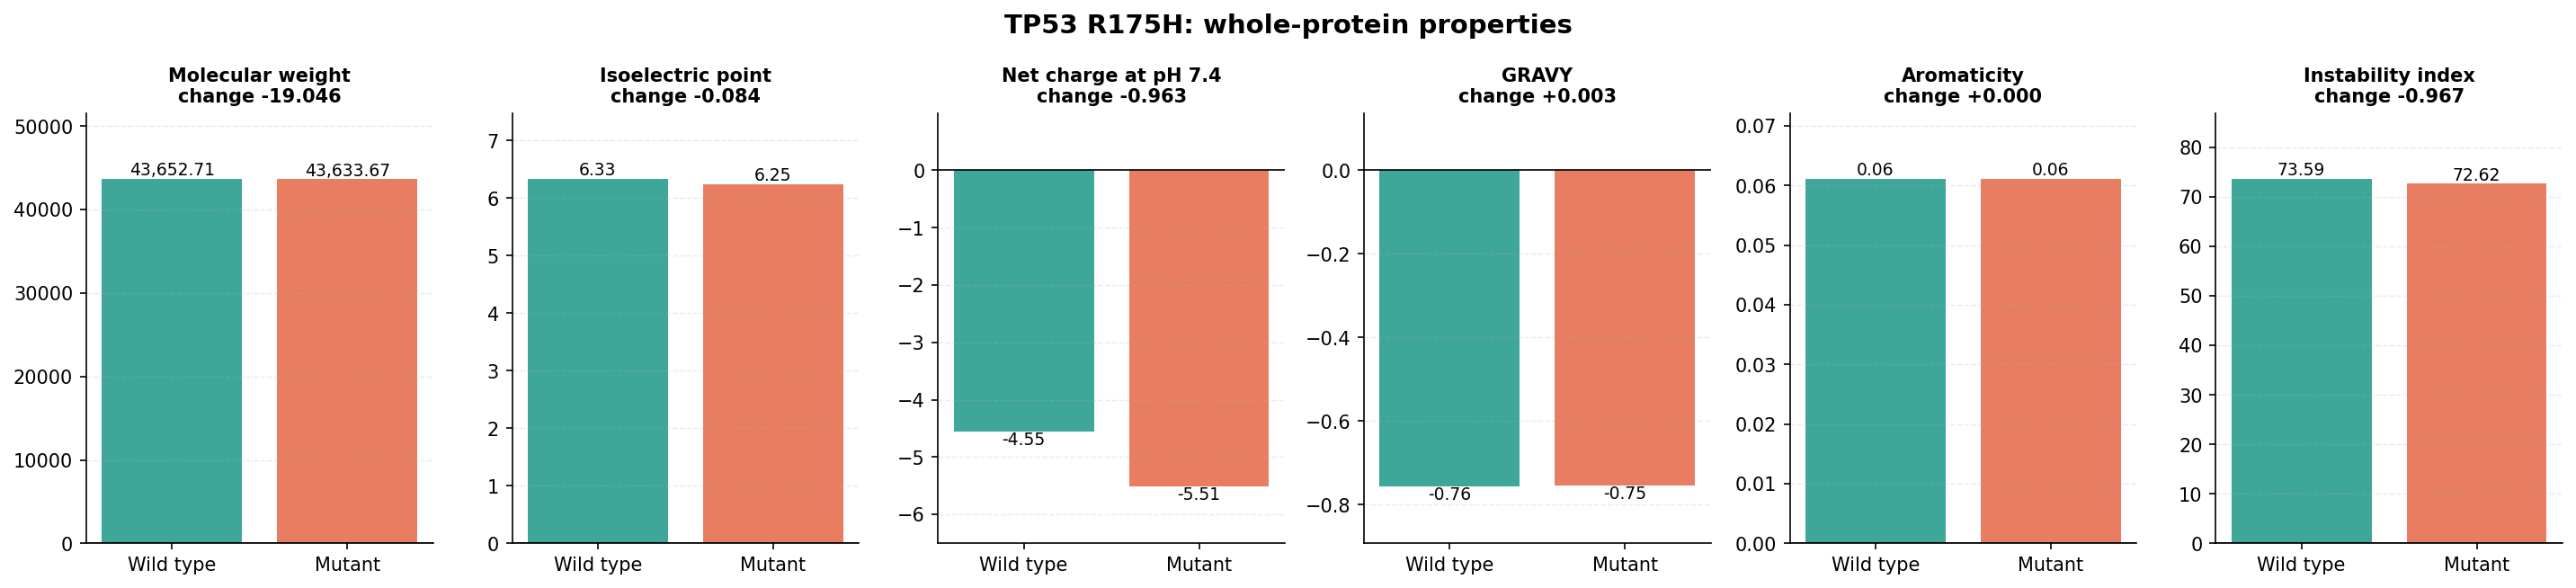

In [25]:
plot_wt_vs_mutant(
    protein_properties[["Property", "Wild_Type", "Mutant"]],
    f"{GENE_NAME} {VARIANT_TAG}: whole-protein properties",
    f"{GENE_NAME}_{VARIANT_TAG}_protein_properties.png"
)

### 11.2 Net Charge Across pH

We will calculate the net charge of the whole wild-type and mutant proteins across the pH range from 0 to 14.

Charge is the property that a substitution between a strongly basic residue and a weakly basic one changes most. Plotting it against pH shows where the two proteins differ and by how much. The right panel shows the difference between mutant and wild type. The dashed line marks physiological pH, 7.4.

Biopython uses its own set of pKa values for this calculation, so the numbers are close to, but not identical with, the side-chain calculation in section 10.1.

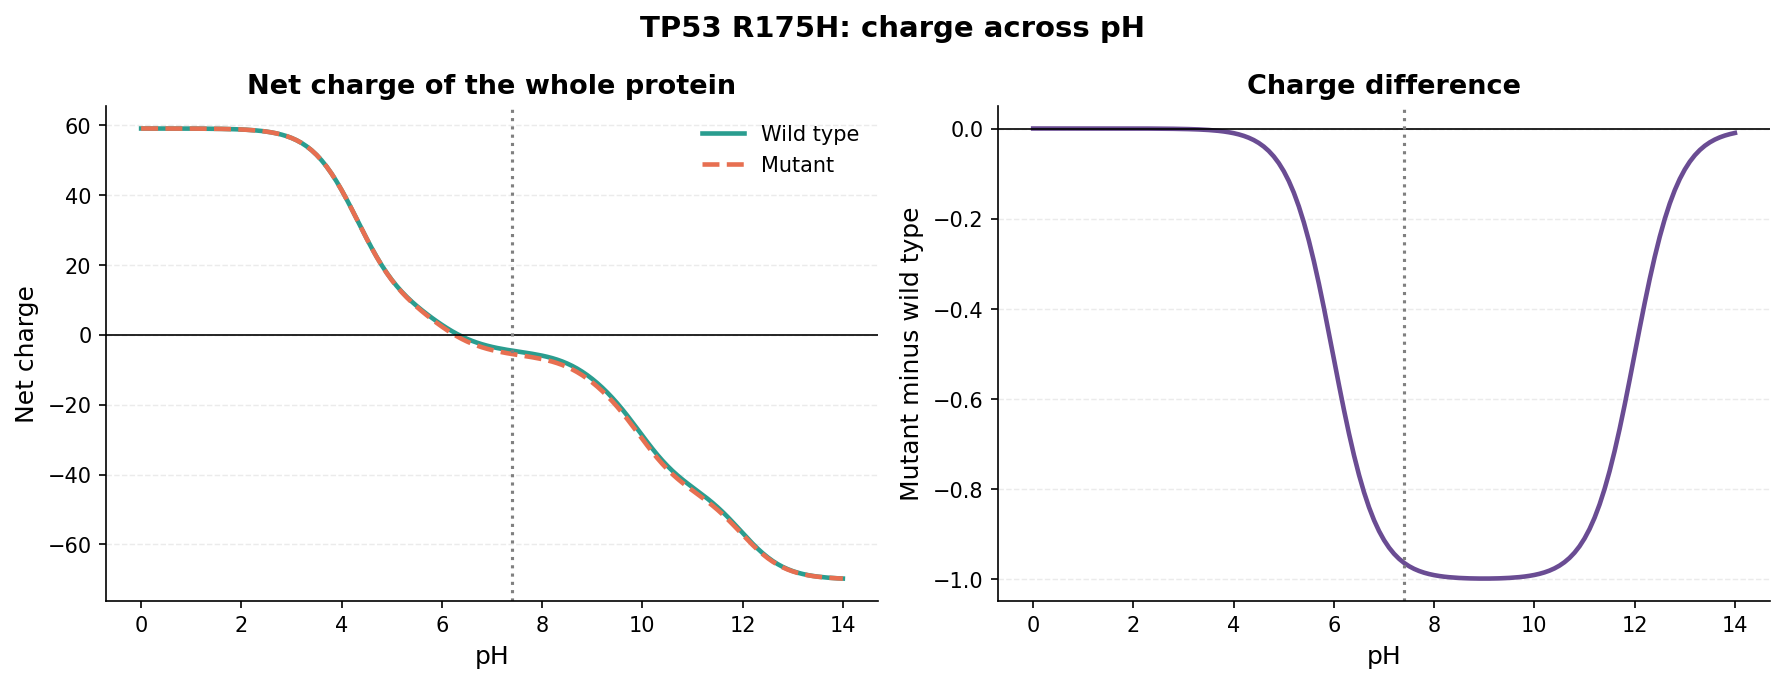

Net charge at pH 7.4: wild type -4.55, mutant -5.51, difference -0.96


In [26]:
ph_values = np.arange(0, 14.01, 0.1)

wt_charge_curve = np.array([wt_analysis.charge_at_pH(p) for p in ph_values])
mut_charge_curve = np.array([mut_analysis.charge_at_pH(p) for p in ph_values])
charge_difference_curve = mut_charge_curve - wt_charge_curve

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), dpi=150)

axes[0].plot(ph_values, wt_charge_curve, color=COLOR_WILD_TYPE, linewidth=2.2, label="Wild type")
axes[0].plot(ph_values, mut_charge_curve, color=COLOR_MUTANT, linewidth=2.2, linestyle="--", label="Mutant")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("pH", fontsize=12)
axes[0].set_ylabel("Net charge", fontsize=12)
axes[0].set_title("Net charge of the whole protein", fontsize=13, fontweight="bold")
axes[0].legend(frameon=False)

axes[1].plot(ph_values, charge_difference_curve, color="#6A4C93", linewidth=2.2)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("pH", fontsize=12)
axes[1].set_ylabel("Mutant minus wild type", fontsize=12)
axes[1].set_title("Charge difference", fontsize=13, fontweight="bold")

for ax in axes:
    ax.axvline(7.4, color="gray", linestyle=":", linewidth=1.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.25)

fig.suptitle(f"{GENE_NAME} {VARIANT_TAG}: charge across pH", fontsize=14, fontweight="bold")
fig.tight_layout()
save_figure(fig, f"{GENE_NAME}_{VARIANT_TAG}_charge_vs_pH.png")
plt.show()

index_7_4 = int(np.argmin(np.abs(ph_values - 7.4)))
print(f"Net charge at pH 7.4: wild type {wt_charge_curve[index_7_4]:+.2f}, "
      f"mutant {mut_charge_curve[index_7_4]:+.2f}, difference {charge_difference_curve[index_7_4]:+.2f}")

## 12. Mutation Characterization

We will compare the residue properties before and after the substitution.

A substitution can preserve some biochemical characteristics while changing others.

For example, the wild-type and mutant residues can be compared according to:

* side-chain charge at pH 7.4
* polarity
* hydropathy
* BLOSUM62 score and Grantham distance

This provides a simple rule-based characterization of the observed substitution.

A side-chain charge change of at least half a charge unit at pH 7.4 is counted as a charge change.

### Important note

This classification is based only on residue properties. It does not predict pathogenicity or establish whether the mutation is functionally damaging.

In [27]:
CHARGE_CHANGE_THRESHOLD = 0.5   # in charge units at pH 7.4


def describe_substitution(wt_aa, mut_aa):
    """One row that characterizes an amino-acid substitution. The same function is used for every variant."""
    wt_f = residue_facts(wt_aa)
    mut_f = residue_facts(mut_aa)
    grantham = grantham_distance(wt_aa, mut_aa)
    charge_shift = mut_f["Charge_at_pH_7_4"] - wt_f["Charge_at_pH_7_4"]

    return {
        "BLOSUM62_score": int(blosum62[wt_aa, mut_aa]),
        "Grantham_distance": grantham,
        "Grantham_class": grantham_class(grantham),
        "Hydropathy_change": round(mut_f["Hydropathy"] - wt_f["Hydropathy"], 2),
        "Charge_change_pH_7_4": round(charge_shift, 2),
        "Charge_class": "charge change" if abs(charge_shift) >= CHARGE_CHANGE_THRESHOLD else "no charge change",
        "Molecular_weight_change": round(mut_f["Molecular_Weight"] - wt_f["Molecular_Weight"], 2),
        "Polarity_class_change": "yes" if wt_f["Polarity"] != mut_f["Polarity"] else "no",
    }


substitution_description = describe_substitution(WILDTYPE_AA, MUTANT_AA)

property_change_df = pd.DataFrame([{
    "Position": MUTATION_POSITION,
    "Wild_Type": WILDTYPE_AA,
    "Mutant": MUTANT_AA,
    "Wild_Type_Charge_pH_7_4": round(wt_facts["Charge_at_pH_7_4"], 3),
    "Mutant_Charge_pH_7_4": round(mut_facts["Charge_at_pH_7_4"], 3),
    "Wild_Type_Polarity": wt_facts["Polarity"],
    "Mutant_Polarity": mut_facts["Polarity"],
    **substitution_description,
}])

display(property_change_df.T)

,0
Position,175
Wild_Type,R
Mutant,H
Wild_Type_Charge_pH_7_4,1.0
Mutant_Charge_pH_7_4,0.038
Wild_Type_Polarity,polar
Mutant_Polarity,polar
BLOSUM62_score,0
Grantham_distance,29
Grantham_class,conservative


In [28]:
if substitution_description["Charge_class"] == "charge change":
    charge_change = f"Side-chain charge change at pH 7.4 ({substitution_description['Charge_change_pH_7_4']:+.2f})"
else:
    charge_change = "No meaningful side-chain charge change at pH 7.4"

if wt_facts["Polarity"] == mut_facts["Polarity"]:
    polarity_change = "No polarity-category change"
else:
    polarity_change = "Polarity-category change"

similarity_note = (
    f"BLOSUM62 score {substitution_description['BLOSUM62_score']}, "
    f"Grantham distance {substitution_description['Grantham_distance']} "
    f"({substitution_description['Grantham_class']})"
)

print("Mutation:", VARIANT_TAG)
print(charge_change)
print(polarity_change)
print(similarity_note)

Mutation: R175H
Side-chain charge change at pH 7.4 (-0.96)
No polarity-category change
BLOSUM62 score 0, Grantham distance 29 (conservative)


### 12.1 Annotation Context from UniProt

We will ask UniProt what is known about the region around the mutation position.

Two questions matter here. First, does the position lie inside an annotated domain, region, binding site or modified residue? Second, is this exact variant already listed in UniProt as a natural variant, and with what description?

This part depends on a second UniProt download. If that download fails, or if UniProt returns no annotation for the protein, the notebook prints a message and continues, because nothing else in the notebook depends on it. An empty table means that no annotation was returned. It does not mean that the position has no function.

In [29]:
def fetch_uniprot_json(accession):
    """Download the full UniProtKB entry (sequence, features and annotations) as JSON."""
    response = requests.get(f"https://rest.uniprot.org/uniprotkb/{accession}.json", timeout=30)
    response.raise_for_status()
    return response.json()


def _position_value(position):
    """The number inside a UniProt position such as {"value": 175, "modifier": "EXACT"}, or None."""
    if isinstance(position, dict) and isinstance(position.get("value"), int):
        return position["value"]
    return None


def feature_range(feature):
    """Start and end position of a UniProt feature, or (None, None) when they are not exact numbers."""
    location = feature.get("location")
    if not isinstance(location, dict):
        return None, None
    start = _position_value(location.get("start"))
    end = _position_value(location.get("end"))
    if start is None or end is None:
        return None, None
    return start, end


try:
    uniprot_data = fetch_uniprot_json(UNIPROT_ID)
    if not isinstance(uniprot_data, dict):
        uniprot_data = {}
    features = uniprot_data.get("features", [])
    # keep only well-formed entries, so an unexpected layout cannot break the notebook
    uniprot_features = [f for f in features if isinstance(f, dict)] if isinstance(features, list) else []
    UNIPROT_ANNOTATIONS_RETRIEVED = True
except (requests.RequestException, ValueError) as error:
    uniprot_data = {}
    uniprot_features = []
    UNIPROT_ANNOTATIONS_RETRIEVED = False
    print("UniProt annotations could not be retrieved:", error)
    print("The rest of the notebook does not depend on them.")

if UNIPROT_ANNOTATIONS_RETRIEVED:
    print("Annotation features retrieved:", len(uniprot_features))

    # The FASTA sequence and the JSON sequence should be identical
    sequence_entry = uniprot_data.get("sequence")
    json_sequence = sequence_entry.get("value") if isinstance(sequence_entry, dict) else None
    if isinstance(json_sequence, str) and json_sequence.upper() != wildtype_sequence:
        print("WARNING: the sequence in the annotation download differs from the FASTA sequence. "
              "The entry may have been updated between the two downloads. Run the notebook again.")

Annotation features retrieved: 1523


In [30]:
# Features that cover the mutation position (the whole-protein chain and natural variants are handled separately)
rows = []
for feature in uniprot_features:
    feature_type = feature.get("type", "")
    start, end = feature_range(feature)

    if feature_type in ("Chain", "Natural variant") or start is None:
        continue
    if start <= MUTATION_POSITION <= end:
        rows.append({
            "Type": feature_type,
            "Start": start,
            "End": end,
            "Description": str(feature.get("description", "")),
        })

overlapping_features_df = pd.DataFrame(rows, columns=["Type", "Start", "End", "Description"])

if len(overlapping_features_df):
    print(f"Annotated features that cover position {MUTATION_POSITION}:")
    display(overlapping_features_df)
else:
    print(f"No annotated feature covering position {MUTATION_POSITION} was returned.")

Annotated features that cover position 175:


,Type,Start,End,Description
0,DNA binding,102,292,
1,Region,1,320,Interaction with CCAR2
2,Region,100,370,Interaction with HIPK1
3,Region,100,300,Required for interaction with ZNF385A
4,Region,113,236,Required for interaction with FBXO42
5,Region,116,292,Interaction with AXIN1
6,Helix,174,176,


In [31]:
# Is this variant already listed in UniProt as a natural variant?
listed_variants = []
for feature in uniprot_features:
    if feature.get("type") != "Natural variant":
        continue
    start, end = feature_range(feature)
    if start == MUTATION_POSITION and end == MUTATION_POSITION:
        change = feature.get("alternativeSequence")
        change = change if isinstance(change, dict) else {}
        alternatives = change.get("alternativeSequences")
        alternatives = alternatives if isinstance(alternatives, list) else []
        listed_variants.append({
            "Original": str(change.get("originalSequence", "")),
            "Alternative": ", ".join(str(a) for a in alternatives),
            "Description": str(feature.get("description", "")),
        })

matching_variants = [
    v for v in listed_variants if MUTANT_AA in [a.strip() for a in v["Alternative"].split(",")]
]

if matching_variants:
    known_variant_note = f"{VARIANT_TAG} is listed in UniProt as a natural variant: " + matching_variants[0]["Description"]
elif listed_variants:
    known_variant_note = (f"{VARIANT_TAG} is not listed in UniProt, but other variants are listed "
                          f"at position {MUTATION_POSITION}.")
elif UNIPROT_ANNOTATIONS_RETRIEVED:
    known_variant_note = f"No natural variant is listed in UniProt at position {MUTATION_POSITION}."
else:
    known_variant_note = "UniProt annotations were not available."

print(known_variant_note)

if listed_variants:
    display(pd.DataFrame(listed_variants))

R175H is listed in UniProt as a natural variant: in LFS; germline mutation and in sporadic cancers; somatic mutation; does not induce SNAI1 degradation; reduces interaction with ZNF385A; dbSNP:rs28934578


,Original,Alternative,Description
0,R,C,in sporadic cancers; somatic mutation; dbSNP:r...
1,R,G,in LFS; germline mutation and in sporadic canc...
2,R,H,in LFS; germline mutation and in sporadic canc...
3,R,L,in LFS; germline mutation and in sporadic canc...
4,R,P,in sporadic cancers; somatic mutation
5,R,Q,in a sporadic cancer; somatic mutation
6,R,S,in sporadic cancers; somatic mutation


## 13. Mutation Position Visualization

We will place the mutation within the full protein sequence.

A mutation position becomes easier to interpret when it is shown relative to the whole protein. If UniProt annotates domains or DNA-binding regions, they are shaded on the protein so that it is visible whether the mutation lies inside one of them.

### 13.1 Local Sequence Context

Before the figure, we will print the sequence around the mutation for the wild-type and the mutant protein. The mutated residue is shown in square brackets.

In [32]:
CONTEXT = 10

left = max(0, MUTATION_POSITION - 1 - CONTEXT)
right = min(len(wildtype_sequence), MUTATION_POSITION + CONTEXT)


def marked_window(sequence):
    return (sequence[left:MUTATION_POSITION - 1]
            + "[" + sequence[MUTATION_POSITION - 1] + "]"
            + sequence[MUTATION_POSITION:right])


print(f"Positions {left + 1} to {right}")
print("Wild type:", marked_window(wildtype_sequence))
print("Mutant:   ", marked_window(mutant_sequence))

Positions 165 to 185
Wild type: QSQHMTEVVR[R]CPHHERCSDS
Mutant:    QSQHMTEVVR[H]CPHHERCSDS


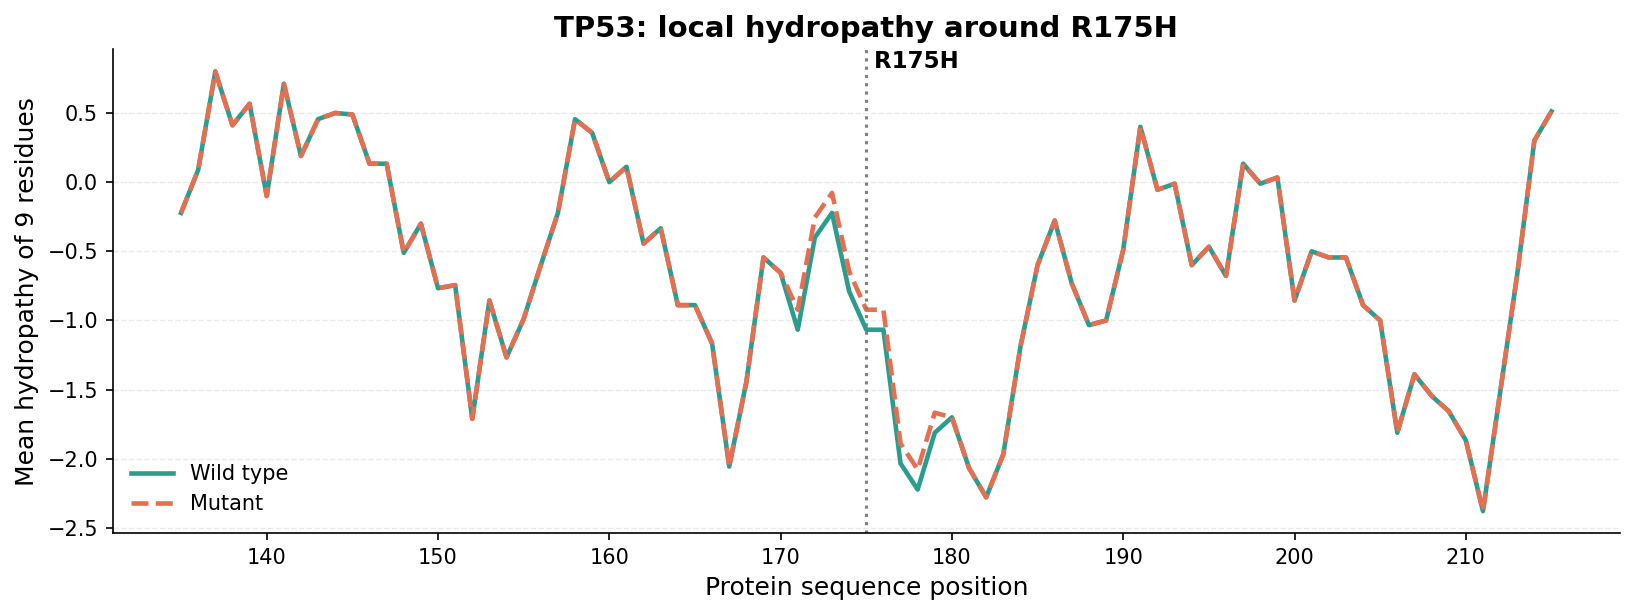

Largest change in the local average hydropathy: 0.144
Every window that contains the mutated residue changes by exactly 0.144, which is the residue change divided by 9.


In [33]:
PROFILE_WINDOW = 9   # residues averaged for the local hydropathy profile (must be odd)
PROFILE_RANGE = 40   # residues shown on each side of the mutation

if len(wildtype_sequence) >= PROFILE_WINDOW:
    wt_profile = np.array(wt_analysis.protein_scale(ProtParamData.kd, PROFILE_WINDOW))
    mut_profile = np.array(mut_analysis.protein_scale(ProtParamData.kd, PROFILE_WINDOW))
    centers = np.arange(len(wt_profile)) + (PROFILE_WINDOW + 1) // 2   # position of the middle residue of each window

    shown = (centers >= MUTATION_POSITION - PROFILE_RANGE) & (centers <= MUTATION_POSITION + PROFILE_RANGE)

    fig, ax = plt.subplots(figsize=(11, 4.2), dpi=150)
    ax.plot(centers[shown], wt_profile[shown], color=COLOR_WILD_TYPE, linewidth=2.2, label="Wild type")
    ax.plot(centers[shown], mut_profile[shown], color=COLOR_MUTANT, linewidth=2.2, linestyle="--", label="Mutant")
    ax.axvline(MUTATION_POSITION, color="gray", linestyle=":", linewidth=1.5)
    ax.text(MUTATION_POSITION, ax.get_ylim()[1], f" {VARIANT_TAG}", va="top", fontsize=11, fontweight="bold")
    ax.set_xlabel("Protein sequence position", fontsize=12)
    ax.set_ylabel(f"Mean hydropathy of {PROFILE_WINDOW} residues", fontsize=12)
    ax.set_title(f"{GENE_NAME}: local hydropathy around {VARIANT_TAG}", fontsize=14, fontweight="bold")
    ax.legend(frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", linestyle="--", linewidth=0.7, alpha=0.25)
    fig.tight_layout()
    save_figure(fig, f"{GENE_NAME}_{VARIANT_TAG}_local_hydropathy.png")
    plt.show()

    largest_local_change = float(np.max(np.abs(mut_profile - wt_profile)))
    print(f"Largest change in the local average hydropathy: {largest_local_change:.3f}")
    print(f"Every window that contains the mutated residue changes by exactly "
          f"{abs(hydropathy_change) / PROFILE_WINDOW:.3f}, which is the residue change divided by {PROFILE_WINDOW}.")
else:
    print("The protein is shorter than the profile window, so no local profile is drawn.")

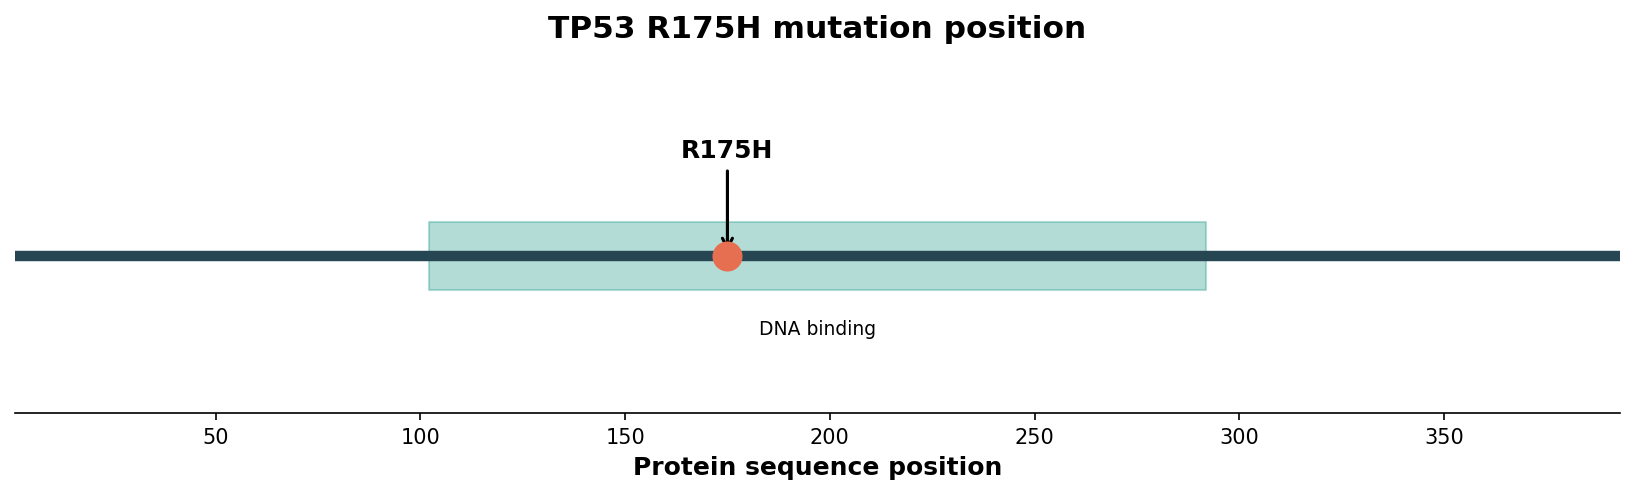

In [34]:
DOMAIN_TYPES = ("Domain", "DNA binding", "Zinc finger", "Repeat")

domain_features = []
for feature in uniprot_features:
    start, end = feature_range(feature)
    if feature.get("type") in DOMAIN_TYPES and start is not None:
        domain_features.append((start, end, str(feature.get("description") or feature.get("type"))))

protein_length = len(wildtype_sequence)

fig, ax = plt.subplots(figsize=(11, 3.4), dpi=150)

ax.plot(
    [1, protein_length],
    [0, 0],
    linewidth=5,
    color="#264653",
    solid_capstyle="butt"
)

for start, end, label in domain_features:
    ax.fill_between([start, end], -0.07, 0.07, color=COLOR_WILD_TYPE, alpha=0.35)
    ax.text((start + end) / 2, -0.13, label[:30], ha="center", va="top", fontsize=9)

ax.scatter(
    MUTATION_POSITION,
    0,
    s=180,
    zorder=5,
    color=COLOR_MUTANT
)

ax.annotate(
    VARIANT_TAG,
    xy=(MUTATION_POSITION, 0),
    xytext=(MUTATION_POSITION, 0.2),
    ha="center",
    fontsize=12,
    fontweight="bold",
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.5
    )
)

ax.set_xlim(1, protein_length)
ax.set_ylim(-0.32, 0.38)

ax.set_xlabel(
    "Protein sequence position",
    fontsize=12,
    fontweight="bold"
)

ax.set_yticks([])

ax.set_title(
    f"{GENE_NAME} {VARIANT_TAG} mutation position",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

plt.tight_layout()
save_figure(fig, f"{GENE_NAME}_{VARIANT_TAG}_position.png")
plt.show()

if not domain_features:
    print("No annotated domain was returned by UniProt, so none is shaded.")

## 14. Comparing Several Variants

We will use the same functions to compare several variants of the same protein in one table.

The workflow was written for one variant, but nothing in it is specific to R175H. Each variant in the list is first checked against the reference sequence. If the wild-type residue in the variant does not match the residue at that position, the variant is skipped and the reason is shown, in the same way that section 5 protects the main variant.

The default list contains well-known TP53 hotspot variants. It can be replaced with any list of variants of the protein chosen in section 2.

Because the scores describe the type of amino-acid change and not the position, variants can look very different in the table and still be similar in biological importance. For example, R175H has a Grantham distance of only 29, which is conservative, and it is nevertheless one of the most frequently observed TP53 variants in cancer. R175H is widely reported to destabilize the folded DNA-binding domain, an effect that no sequence-level score in this notebook can see.

In [35]:
VARIANTS_TO_COMPARE = ["R175H", "G245S", "R248Q", "R248W", "R249S", "R273H", "R273C", "R282W"]

rows = []

for variant_text in VARIANTS_TO_COMPARE:
    wt_aa_i, position_i, mut_aa_i = parse_variant(variant_text)

    observed = wildtype_sequence[position_i - 1] if position_i <= len(wildtype_sequence) else None
    if observed != wt_aa_i:
        rows.append({"Variant": variant_text,
                     "Status": f"skipped: position {position_i} holds {observed}, not {wt_aa_i}"})
        continue

    rows.append({"Variant": variant_text, "Status": "ok", **describe_substitution(wt_aa_i, mut_aa_i)})

variant_comparison_df = pd.DataFrame(rows)
display(variant_comparison_df)

,Variant,Status,BLOSUM62_score,Grantham_distance,Grantham_class,Hydropathy_change,Charge_change_pH_7_4,Charge_class,Molecular_weight_change,Polarity_class_change
0,R175H,ok,0,29,conservative,1.3,-0.96,charge change,-19.05,no
1,G245S,ok,0,55,moderately conservative,-0.4,0.00,no charge change,30.03,yes
2,R248Q,ok,1,43,conservative,1.0,-1.00,charge change,-28.06,no
3,R248W,ok,-3,101,moderately radical,3.6,-1.00,charge change,30.02,yes
4,R249S,ok,-1,109,moderately radical,3.7,-1.00,charge change,-69.11,no
5,R273H,ok,0,29,conservative,1.3,-0.96,charge change,-19.05,no
6,R273C,ok,-3,180,radical,7.0,-1.14,charge change,-53.04,no
7,R282W,ok,-3,101,moderately radical,3.6,-1.00,charge change,30.02,yes


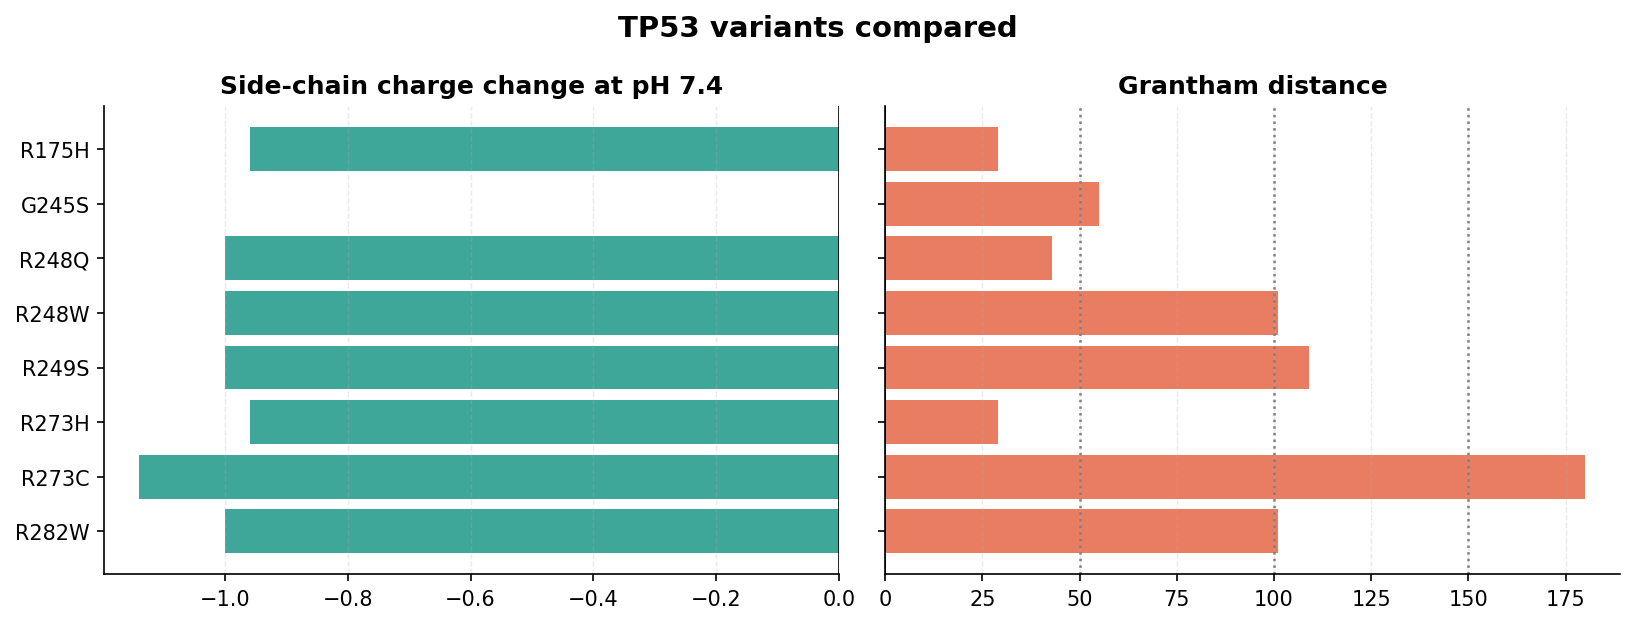

In [36]:
# Figure: charge change and Grantham distance for the variants that passed the check
ok_df = variant_comparison_df[variant_comparison_df["Status"] == "ok"]

if len(ok_df):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), dpi=150, sharey=True)

    axes[0].barh(ok_df["Variant"], ok_df["Charge_change_pH_7_4"], color=COLOR_WILD_TYPE, alpha=0.9)
    axes[0].set_title("Side-chain charge change at pH 7.4", fontsize=12, fontweight="bold")

    axes[1].barh(ok_df["Variant"], ok_df["Grantham_distance"], color=COLOR_MUTANT, alpha=0.9)
    axes[1].set_title("Grantham distance", fontsize=12, fontweight="bold")
    for boundary in (50, 100, 150):
        axes[1].axvline(boundary, color="gray", linestyle=":", linewidth=1.2)

    for ax in axes:
        ax.axvline(0, color="black", linewidth=0.8)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.25)

    axes[0].invert_yaxis()   # the y axis is shared, so this puts the first variant at the top

    fig.suptitle(f"{GENE_NAME} variants compared", fontsize=14, fontweight="bold")
    fig.tight_layout()
    save_figure(fig, f"{GENE_NAME}_variant_comparison.png")
    plt.show()
else:
    print("No variant passed the reference check, so no figure is drawn.")

## 15. Mutation Summary

We will collect the main results into one summary table.

The summary joins the sequence information, the residue-level results, the substitution scores and the annotation context, so that a single table describes the variant.

In [37]:
mutation_summary = {
    "Protein": GENE_NAME,
    "UniProt_ID": UNIPROT_ID,
    "UniProt_Sequence_Version": SEQUENCE_VERSION,
    "Retrieved_On": RETRIEVED_ON,
    "Variant": VARIANT_NAME,
    "Position": MUTATION_POSITION,
    "Wild_Type_Amino_Acid": WILDTYPE_AA,
    "Mutant_Amino_Acid": MUTANT_AA,
    "Wild_Type_Length": len(wildtype_sequence),
    "Mutant_Length": len(mutant_sequence),
    "Length_Change": len(mutant_sequence) - len(wildtype_sequence),
    "BLOSUM62_Score": substitution_description["BLOSUM62_score"],
    "Grantham_Distance": substitution_description["Grantham_distance"],
    "Grantham_Class": substitution_description["Grantham_class"],
    "Charge_Change": charge_change,
    "Polarity_Change": polarity_change,
    "UniProt_Annotation": known_variant_note,
}

mutation_summary_df = pd.DataFrame([mutation_summary])

display(mutation_summary_df.T)

,0
Protein,TP53
UniProt_ID,P04637
UniProt_Sequence_Version,4
Retrieved_On,2026-09-21
Variant,p.Arg175His (R175H)
Position,175
Wild_Type_Amino_Acid,R
Mutant_Amino_Acid,H
Wild_Type_Length,393
Mutant_Length,393


## 16. Exporting Results

We will save the results in the results folder created in section 2.

The folder name contains the accession and the variant, so results for different variants are kept apart and never overwrite each other. The folder will contain:

* the tables as CSV files
* a text report
* a small metadata file with the software versions, the UniProt sequence version, the retrieval date and a checksum of the sequence that was analyzed
* the figures and the reference FASTA file

The metadata file makes it possible to see later exactly which sequence and which software produced the results.

In [38]:
mutation_df.to_csv(OUTPUT_DIR / "mutation_comparison.csv", index=False)
protein_properties.to_csv(OUTPUT_DIR / "protein_property_comparison.csv", index=False)
property_change_df.to_csv(OUTPUT_DIR / "amino_acid_property_change.csv", index=False)
variant_comparison_df.to_csv(OUTPUT_DIR / "variant_comparison.csv", index=False)
overlapping_features_df.to_csv(OUTPUT_DIR / "uniprot_features_at_position.csv", index=False)
mutation_summary_df.to_csv(OUTPUT_DIR / "mutation_summary.csv", index=False)

print("Analysis results exported successfully.")

Analysis results exported successfully.


In [39]:
lines = [
    "Protein Mutation Analyzer Report",
    "=" * 45,
    "",
    f"Protein: {GENE_NAME}",
    f"UniProt ID: {UNIPROT_ID} (sequence version {SEQUENCE_VERSION}, retrieved {RETRIEVED_ON})",
    f"Variant: {VARIANT_NAME}",
    f"Position: {MUTATION_POSITION}",
    f"Wild-type residue: {WILDTYPE_AA}",
    f"Mutant residue: {MUTANT_AA}",
    "",
    "Sequence Information",
    "-" * 45,
    f"Wild-type length: {len(wildtype_sequence)} aa",
    f"Mutant length: {len(mutant_sequence)} aa",
    f"Differences found: {', '.join(mutation_df['Notation']) if len(mutation_df) else 'none'}",
    "",
    "Residue Property Changes",
    "-" * 45,
    f"Charge: {charge_change}",
    f"Side-chain charge at pH 7.4: {wt_facts['Charge_at_pH_7_4']:+.2f} -> {mut_facts['Charge_at_pH_7_4']:+.2f}",
    f"Polarity: {polarity_change}",
    f"Hydropathy change: {hydropathy_change:+.2f}",
    f"Substitution scores: {similarity_note}",
    "",
    "Protein-Level Properties",
    "-" * 45,
]

for _, row in protein_properties.iterrows():
    lines.append(
        f"{row['Property']}: WT={row['Wild_Type']:.4f}, "
        f"Mutant={row['Mutant']:.4f}, Change={row['Change']:.4f}"
    )

lines += ["", "UniProt Annotation", "-" * 45, known_variant_note]

if len(overlapping_features_df):
    for _, row in overlapping_features_df.iterrows():
        lines.append(f"{row['Type']} {row['Start']}-{row['End']}: {row['Description']}")

lines += [
    "",
    "Note",
    "-" * 45,
    "These values describe sequence-level differences. They do not predict pathogenicity or",
    "establish an effect on protein structure or function.",
]

(OUTPUT_DIR / "protein_mutation_report.txt").write_text("\n".join(lines) + "\n")

print("Text report created successfully.")

Text report created successfully.


In [40]:
analysis_metadata = {
    "protein": GENE_NAME,
    "uniprot_id": UNIPROT_ID,
    "uniprot_sequence_version": SEQUENCE_VERSION,
    "retrieved_on": RETRIEVED_ON,
    "sequence_sha256": SEQUENCE_SHA256,
    "sequence_length": len(wildtype_sequence),
    "variant_input": VARIANT,
    "variant": VARIANT_NAME,
    "uniprot_annotations_retrieved": UNIPROT_ANNOTATIONS_RETRIEVED,
    "software": {
        "python": sys.version.split()[0],
        "biopython": Bio.__version__,
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "matplotlib": matplotlib.__version__,
    },
}

(OUTPUT_DIR / "analysis_metadata.json").write_text(json.dumps(analysis_metadata, indent=2))

print("Metadata file created successfully.")
print("\nFiles in", OUTPUT_DIR, ":")
for path in sorted(OUTPUT_DIR.iterdir()):
    print(" ", path.name)

Metadata file created successfully.

Files in results_P04637_R175H :
  P04637.fasta
  R175H_residue_property_comparison.png
  TP53_R175H_charge_vs_pH.png
  TP53_R175H_local_hydropathy.png
  TP53_R175H_position.png
  TP53_R175H_protein_properties.png
  TP53_variant_comparison.png
  amino_acid_property_change.csv
  analysis_metadata.json
  mutation_comparison.csv
  mutation_summary.csv
  protein_mutation_report.txt
  protein_property_comparison.csv
  uniprot_features_at_position.csv
  variant_comparison.csv


### 16.1 Download the Results

We will pack the whole results folder into one zip file. In Google Colab the file is downloaded to your computer. Outside Colab, the path of the zip file is printed.

In [41]:
archive_path = shutil.make_archive(str(OUTPUT_DIR), "zip", OUTPUT_DIR)

try:
    from google.colab import files
    files.download(archive_path)
except ImportError:
    print("Not running in Google Colab. The zip file is here:", archive_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 17. Final Analysis Summary

The Protein Mutation Analyzer completed a protein-level comparison between the wild-type reference sequence and the mutant sequence. For the TP53 example, the workflow:

1. Retrieved a real TP53 reference sequence from UniProt and checked it.
2. Validated the expected residue at position 175.
3. Generated the R175H mutant sequence and validated it.
4. Compared wild-type and mutant sequences with a function that also handles insertions and deletions.
5. Compared residue-level biochemical properties, including the charge at pH 7.4.
6. Scored the substitution with BLOSUM62 and the Grantham distance.
7. Calculated whole-protein physicochemical descriptors and the net charge across pH.
8. Retrieved the UniProt annotation for the position.
9. Visualized the mutation position, the local hydropathy and the charge.
10. Compared several variants and exported tables, a report and metadata.

The workflow is designed to be reusable with other protein sequences and amino-acid variants.

### Interpretation

The analysis provides computational evidence describing the sequence and physicochemical differences between the reference and mutant proteins.

However, sequence-level property changes alone do not establish structural effects, biological function, or clinical significance. Those questions require additional experimental or computational evidence.

In [42]:
print("=" * 60)
print("PROTEIN MUTATION ANALYZER - FINAL SUMMARY")
print("=" * 60)

print(f"Protein: {GENE_NAME} ({UNIPROT_ID}, sequence version {SEQUENCE_VERSION})")
print(f"Reference length: {len(wildtype_sequence)} aa")
print(f"Variant: {VARIANT_NAME}")
print(f"Mutation position: {MUTATION_POSITION}")
print(f"Wild-type residue: {WILDTYPE_AA}")
print(f"Mutant residue: {MUTANT_AA}")
print(f"Number of differences detected: {len(mutation_df)}")
print(f"Length change: {len(mutant_sequence) - len(wildtype_sequence)} aa")
print(f"Charge comparison: {charge_change}")
print(f"Polarity comparison: {polarity_change}")
print(f"Substitution scores: {similarity_note}")
print(f"UniProt annotation: {known_variant_note}")
print(f"Results folder: {OUTPUT_DIR}")

print("\nAnalysis completed successfully.")

PROTEIN MUTATION ANALYZER - FINAL SUMMARY
Protein: TP53 (P04637, sequence version 4)
Reference length: 393 aa
Variant: p.Arg175His (R175H)
Mutation position: 175
Wild-type residue: R
Mutant residue: H
Number of differences detected: 1
Length change: 0 aa
Charge comparison: Side-chain charge change at pH 7.4 (-0.96)
Polarity comparison: No polarity-category change
Substitution scores: BLOSUM62 score 0, Grantham distance 29 (conservative)
UniProt annotation: R175H is listed in UniProt as a natural variant: in LFS; germline mutation and in sporadic cancers; somatic mutation; does not induce SNAI1 degradation; reduces interaction with ZNF385A; dbSNP:rs28934578
Results folder: results_P04637_R175H

Analysis completed successfully.


## 18. Limitations and Next Steps

### What this notebook cannot tell you

* It compares **sequences**. It has no information about the three-dimensional structure, so it cannot say whether the residue is buried, whether it binds another molecule, or whether the fold is disturbed.
* It does not use **evolutionary conservation**. A residue that is identical in every related protein is far more likely to matter than one that varies, and this notebook does not look at related sequences.
* The charge is an estimate for a free side chain. The real pKa inside a folded protein can differ.
* BLOSUM62 and the Grantham distance describe the type of amino-acid change, not its position.
* The variant must be numbered on the same reference sequence that is downloaded. Isoforms and updated sequence versions can shift the numbering.
* It handles one substitution at a time in the main analysis. The comparison function can report insertions and deletions, but the residue-level analysis is written for a single substitution.

### Where to go next

Tools that add structure and conservation can be used together with this analysis, for example the AlphaFold Protein Structure Database for a predicted structure, and predictors such as PolyPhen-2, SIFT, CADD or AlphaMissense for a computed effect score. Clinical databases such as ClinVar and population databases such as gnomAD show what has been observed in patients and in the general population. The results here describe the sequence change and are a starting point for that kind of work.

# 19. Conclusion

This notebook demonstrates a reproducible protein mutation-analysis workflow using a real human protein and a documented amino-acid variant.

The project combines biological sequence retrieval, validation, mutation detection, physicochemical analysis, substitution scoring, annotation context, visualization, and automated result generation.

Each step checks its own input, and the comparison function is tested on cases with known answers. Although TP53 R175H was used as the demonstration case, the underlying functions can be reused for other protein sequences and amino-acid substitutions by changing `UNIPROT_ID` and `VARIANT`.